In [2]:
import sqlite3 as sq
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

In [3]:
# Conectamos con nuestra base previamente limpiada con SQL. 

conn = sq.connect('data.db')
query = 'SELECT * FROM clean_data'
df = pd.read_sql(query,conn)
conn.close()
df.head()

,limit_bal,gender,education,marriage,age,pay_0,bill_amt1,avg_bill,pay_amt1,payment
0,20000.0,2.0,2,1.0,24.0,2.0,3913.0,1284.000000,0.0,1.0
1,120000.0,2.0,2,2.0,26.0,-1.0,2682.0,2846.166667,0.0,1.0
2,90000.0,2.0,2,2.0,34.0,0.0,29239.0,16942.166667,1518.0,0.0
3,50000.0,2.0,2,1.0,37.0,0.0,46990.0,38555.666667,2000.0,0.0
4,50000.0,1.0,2,1.0,57.0,-1.0,8617.0,18223.166667,2000.0,0.0


In [4]:
# Calculamos la proporción de clientes morosos. 
paid = np.bincount(df['payment'].astype(int))
per = paid[1]/(paid[0]+paid[1]) * 100
print(f"El {per} % de los clientes tiene pagos pendientes")

El 22.12 % de los clientes tiene pagos pendientes


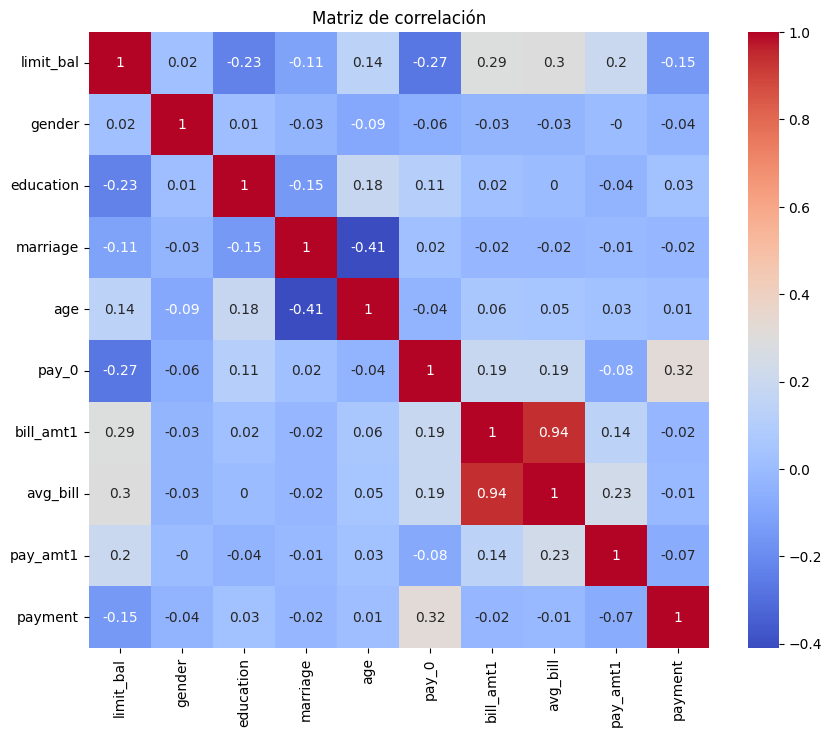

In [5]:
# Calculamos la matriz de correlación y presentamos su mapa de calor. 
plt.figure(figsize=(10,8))
corr_mat = df.corr(numeric_only=True).round(2)

sns.heatmap(data=corr_mat, annot=True, cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()

Podemos comprobar que nuestra función objetivo (payment) está principalmente correlada con el estado de pago del último mes (pay_0). 

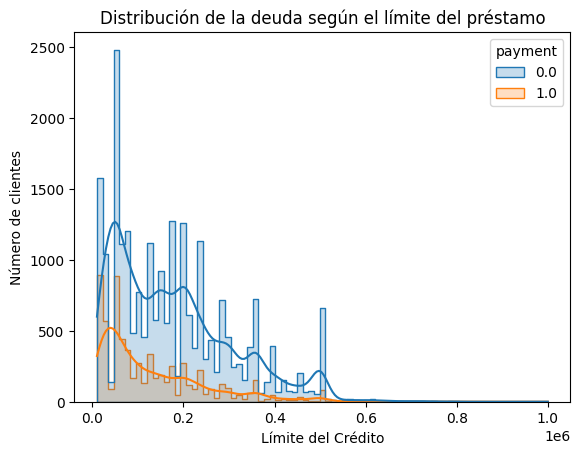

In [6]:
# Hacemos un histograma que nos permita analizar cómo afecta el límite de crédito al estado del pago. 

sns.histplot(data=df, x='limit_bal',hue='payment',kde=True,element="step")

plt.title('Distribución de la deuda según el límite del préstamo')
plt.xlabel('Límite del Crédito')
plt.ylabel('Número de clientes')
plt.show()


Vemos que en general el mayor número de ímpagos se concentra en los límites bajos. 

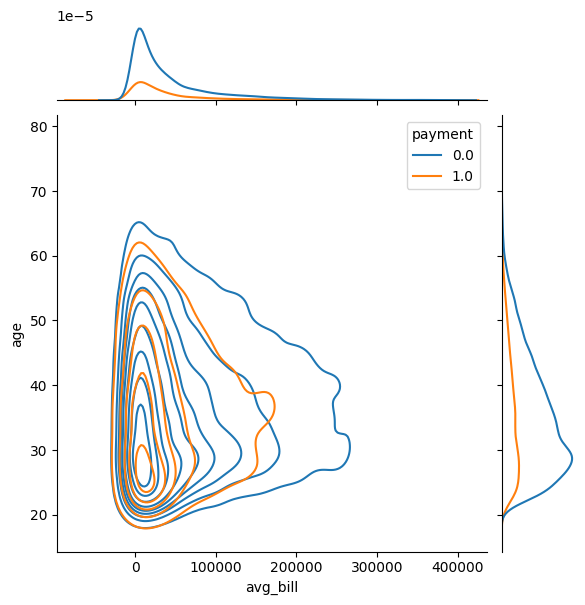

In [7]:
# Hacemos un diagrama para comparar edad y media de facturas, quitándonos el único dato atípico que tiene una media por encima de 400000.
df_filt = df[df['avg_bill'] < 400000]
sns.jointplot(data=df_filt,x='avg_bill',y='age',hue='payment',kind='kde')

En este gráfico bivariado se aprecia: 
1. Los clientes con mayor media de importe por facturas tienden a pagar. 
2. El grupo de los morosos está encapsulado en la esquina inferior izquierda, por lo que los clientes que más se acerquen al rango de entre 20 y 30 años de edad y montos bajos de facturas tenderán a no pagar. 
3. Los clientes de mediana edad o más tienen un comportamiento de pago más fiable. 

Text(0, 0.5, 'Probabilidad de impago')

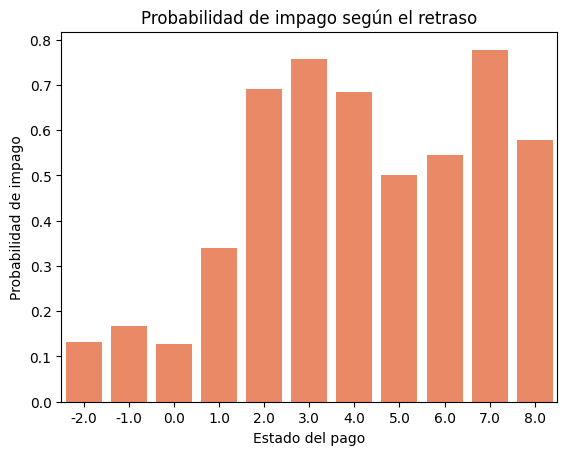

In [8]:
# Estudiamos la relación entre el estado general de deuda y el estado del último pago. 
sns.barplot(data=df, x='pay_0',y='payment',errorbar=None,color='coral')

plt.title('Probabilidad de impago según el retraso')
plt.xlabel('Estado del pago')
plt.ylabel('Probabilidad de impago')

Como sería de esperar, a mayor retraso en los pagos mayor es la probabilidad de no pagar en un futuro. 

In [9]:
# Generamos un nuevo dataframe para reescalar las variables de manera que al aplicar la Regresión Logística no se nos disparen los valores hacia los extremos. 
from sklearn.preprocessing import StandardScaler

columnas_a_escalar = ['limit_bal','age','bill_amt1','avg_bill','pay_amt1']
scalated_df = df.copy()
scalated_df[columnas_a_escalar] = StandardScaler().fit_transform(df[columnas_a_escalar])
scalated_df.head()

,limit_bal,gender,education,marriage,age,pay_0,bill_amt1,avg_bill,pay_amt1,payment
0,-1.136720,2.0,2,1.0,-1.246020,2.0,-0.642501,-0.690692,-0.341942,1.0
1,-0.365981,2.0,2,2.0,-1.029047,-1.0,-0.659219,-0.665997,-0.341942,1.0
2,-0.597202,2.0,2,2.0,-0.161156,0.0,-0.298560,-0.443170,-0.250292,0.0
3,-0.905498,2.0,2,1.0,0.164303,0.0,-0.057491,-0.101507,-0.221191,0.0
4,-0.905498,1.0,2,1.0,2.334029,-1.0,-0.578618,-0.422920,-0.221191,0.0


In [10]:
# Aplicamos el método de la Regresión Logística omitiendo un 20% de los datos. 
X = scalated_df.drop('payment',axis=1)
y = scalated_df['payment']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

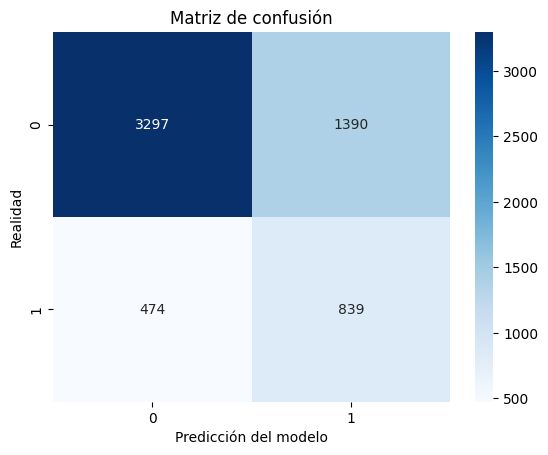

In [11]:
# Calculamos y visualizamos la matriz de confusión. 
conf_mat = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat,annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicción del modelo')
plt.ylabel('Realidad')
plt.title('Matriz de confusión')
plt.show()

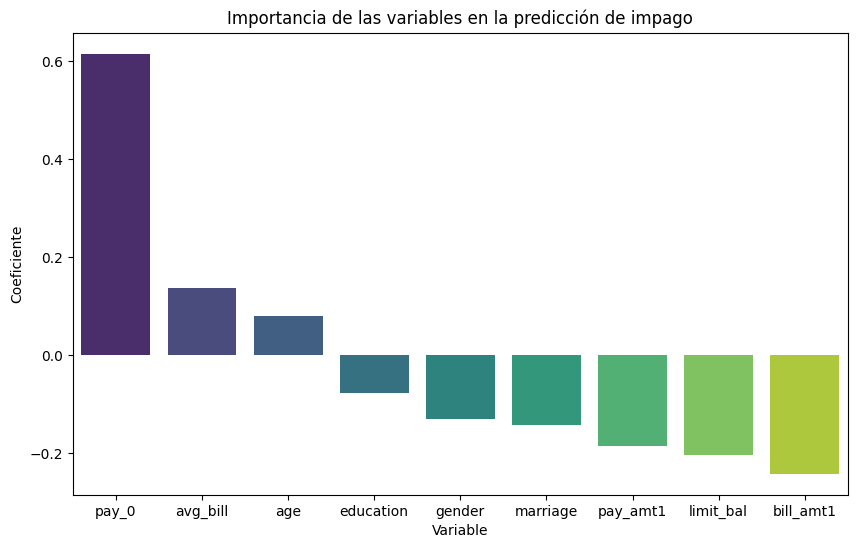

In [12]:
# Calculamos los pesos de las variables explicativas y mostramos su importancia visualmente. 
pesos=model.coef_[0]

importancia = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': pesos
})

importancia = importancia.sort_values(by='Coeficiente',ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(data=importancia,x='Variable',y='Coeficiente',hue='Variable',palette='viridis',legend=False)
plt.title('Importancia de las variables en la predicción de impago')
plt.show()

Confirmamos observaciones previas acerca de la importancia que tienen el estado del último pago como factor de máxima influencia seguido por debajo de la media de facturas y la edad. 

In [13]:
prediction = model.predict(X)
df['leak_prediction']=prediction
name = 'datos_para_powerbi.csv'
df.to_csv(name,index=False)
print(f"¡Exportación del análisis realizado con éxito a {name}")

¡Exportación del análisis realizado con éxito a datos_para_powerbi.csv
